In [16]:
# IMDB 리뷰 데이터를 로드하고 훈련 세트와 검증 세트로 나눕니다. 500개의 단어를 사용합니다.
from keras.datasets import imdb
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)
train_input, val_input, train_target, val_target = train_test_split(train_input, train_target, test_size=0.2, random_state=42)

In [17]:
# 각 샘플의 길이를 100에 맞추고 부족한 경우에는 패딩을 추가합니다.
from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [ ]:
# 모델의 구조를 만듭니다.
import keras

model_lstm = keras.Sequential()
model_lstm.add(keras.layers.Input(shape=(100,)))

# 0~499의 단어 인덱스를 각각 16차원 임베딩 벡터로 변환합니다.
model_lstm.add(keras.layers.Embedding(500,16))

# 8차원 은닉 상태를 출력합니다.
model_lstm.add(keras.layers.LSTM(8))
model_lstm.add(keras.layers.Dense(1, activation='sigmoid'))

In [ ]:
# 모델의 구조를 확인합니다.
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 옵티마이저와 손실함수를 컴파일합니다.
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델을 저장하는 콜백 객체를 만듭니다.
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-lstm-model.keras', save_best_only=True)

# 훈련을 조기에 종료하는 콜백 객체를 만듭니다.
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

# 모델을 훈련합니다. 검증 손실도 함께 출력합니다.
history = model_lstm.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6990 - loss: 0.5802 - val_accuracy: 0.7520 - val_loss: 0.5043
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7857 - loss: 0.4585 - val_accuracy: 0.7888 - val_loss: 0.4495
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7986 - loss: 0.4337 - val_accuracy: 0.7814 - val_loss: 0.4635
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8037 - loss: 0.4207 - val_accuracy: 0.7906 - val_loss: 0.4407
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8080 - loss: 0.4143 - val_accuracy: 0.8044 - val_loss: 0.4304
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8111 - loss: 0.4077 - val_accuracy: 0.8060 - val_loss: 0.4436
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8166 - loss: 0.3990 - val_accuracy: 0.8084 - val_loss: 0.4216
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8203 - loss: 0.3920 - val_a

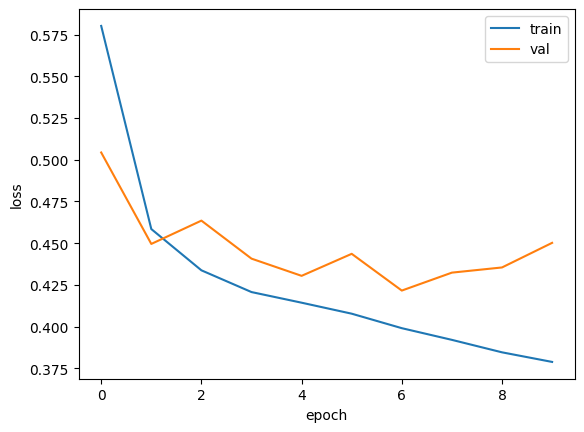

In [ ]:
# 훈련 손실과 검증 손실을 시각화해봅니다.
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [ ]:
import keras
# 드롭아웃을 적용하는 모델의 구조를 만듭니다.
model_dropout = keras.Sequential()
model_dropout.add(keras.layers.Input(shape=(100,)))
model_dropout.add(keras.layers.Embedding(500,16))
# 훈련할 때 들어오는 입력특성의 20%를 무작위로 드롭아웃합니다.
model_dropout.add(keras.layers.LSTM(8, dropout=0.2))
model_dropout.add(keras.layers.Dense(1, activation='sigmoid'))

In [ ]:
# 옵티마이저와 손실함수를 컴파일 합니다.
model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델을 저장하는 콜백 객체를 만듭니다.
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-dropout-model.keras', save_best_only=True)

# 훈련을 조기에 종료시키는 콜백 객체를 만듭니다.
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

# 모델을 훈련합니다. 검증 손실도 출력합니다.
history = model_dropout.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.6344 - loss: 0.6246 - val_accuracy: 0.7590 - val_loss: 0.5253
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7617 - loss: 0.5031 - val_accuracy: 0.7676 - val_loss: 0.4775
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7879 - loss: 0.4617 - val_accuracy: 0.7904 - val_loss: 0.4541
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7993 - loss: 0.4407 - val_accuracy: 0.7734 - val_loss: 0.4664
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8007 - loss: 0.4324 - val_accuracy: 0.8028 - val_loss: 0.4281
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8077 - loss: 0.4194 - val_accuracy: 0.8044 - val_loss: 0.4266
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8062 - loss: 0.4139 - val_accuracy: 0.7988 - val_loss: 0.4305
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8121 - loss: 0.4071 - v

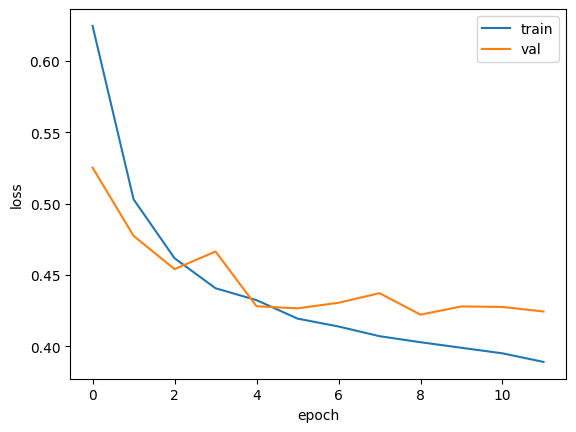

In [ ]:
# 훈련 손실과 검증 손실을 시각화합니다.
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [8]:
# 순환층을 쌓기 위해서 순환층의 마지막 층을 제외하고 모든 타입스텝에서 은닉 상태를 출력하도록 모델의 구조를 만듭니다.
model_2lstm = keras.Sequential()
model_2lstm.add(keras.layers.Input(shape=(100,)))
model_2lstm.add(keras.layers.Embedding(500, 16))
model_2lstm.add(keras.layers.LSTM(8, dropout=0.2, return_sequences=True))
model_2lstm.add(keras.layers.LSTM(8, dropout=0.2))
model_2lstm.add(keras.layers.Dense(1, activation='sigmoid'))
model_2lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 8)         │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,353 (36.54 KB)

 Trainable params: 9,353 (36.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 모델의 옵티마이저와 손실함수를 컴파일합니다.
model_2lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델을 저장하는 콜백 객체를 만듭니다.
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-2lstm-model.keras', save_best_only=True)

# 모델을 조기에 종료하는 객체를 만듭니다.
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

# 모델을 훈련합니다. 검증 손실도 함께 출력합니다.
history = model_2lstm.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6784 - loss: 0.5857 - val_accuracy: 0.7604 - val_loss: 0.4946
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7797 - loss: 0.4778 - val_accuracy: 0.7860 - val_loss: 0.4578
Epoch 3/100
262/313 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7915 - loss: 0.4500

KeyboardInterrupt: 

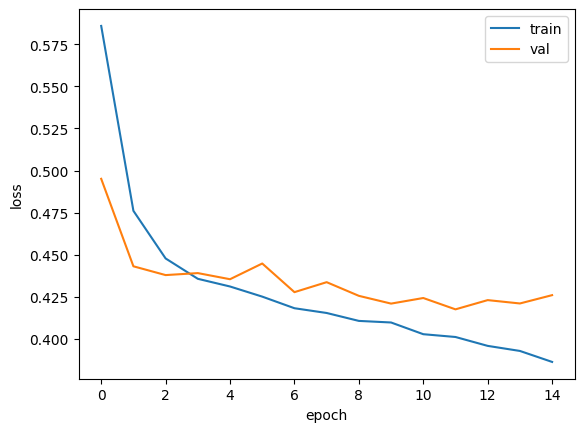

In [ ]:
# 훈련 손실과 검증 손실을 시각화합니다.
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [18]:
import keras

# GRU 신경망 모델의 구조를 만듭니다.
model_gru = keras.Sequential()
model_gru.add(keras.layers.Input(shape=(100,)))
model_gru.add(keras.layers.Embedding(500, 16))
model_gru.add(keras.layers.GRU(8, dropout=0.2))
model_gru.add(keras.layers.Dense(1, activation='sigmoid'))

In [19]:
# 모델의 구조를 확인합니다.
model_gru.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 8)              │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,633 (33.72 KB)

 Trainable params: 8,633 (33.72 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# 옵티마이저와 손실 함수를 컴파일 합니다.
model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델을 저장하는 콜백 객체를 만듭니다.
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-gru-model.keras', save_best_only=True)

# 훈련을 조기에 종료시키는 조기종료 객체를 만듭니다.
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = model_gru.fit(train_seq, train_target, epochs=100, batch_size=64, validation_data=(val_seq, val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6320 - loss: 0.6293 - val_accuracy: 0.7304 - val_loss: 0.5322
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7661 - loss: 0.4904 - val_accuracy: 0.7862 - val_loss: 0.4642
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7869 - loss: 0.4627 - val_accuracy: 0.7858 - val_loss: 0.4534
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7958 - loss: 0.4446 - val_accuracy: 0.7924 - val_loss: 0.4431
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8019 - loss: 0.4342 - val_accuracy: 0.7928 - val_loss: 0.4391
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8045 - loss: 0.4272 - val_accuracy: 0.8012 - val_loss: 0.4302
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8090 - loss: 0.4195 - val_accuracy: 0.8022 - val_loss: 0.4329
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8090 - loss: 0.4186 - val_a

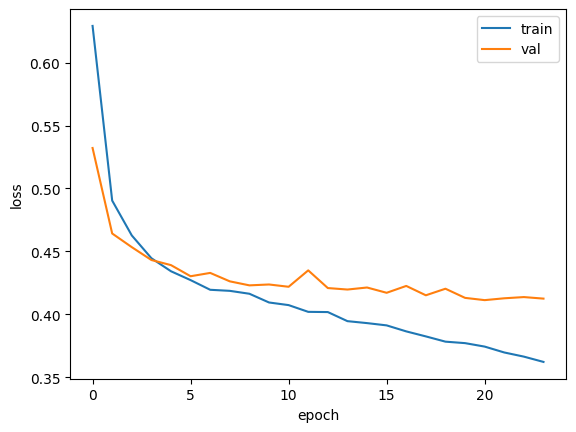

In [21]:
# 훈련 손실과 검증 손실을 시각화합니다.
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [25]:
test_seq = pad_sequences(test_input, maxlen=100)
best_model = keras.models.load_model('best-gru-model.keras')
best_model.evaluate(test_seq, test_target)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8164 - loss: 0.4015


[0.40145301818847656, 0.8164399862289429]

In [1]:
# 파이토치 버전 살펴보기
# IMDB 리뷰 데이터를 로드하고 훈련 세트와 검증 세트로 나눕니다. 500개의 단어를 사용합니다.
from keras.datasets import imdb
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)
train_input, val_input, train_target, val_target = train_test_split(train_input, train_target, test_size=0.2, random_state=42)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [2]:
# 각 샘플의 길이를 100에 맞추고 부족한 경우에는 패딩을 추가합니다.
from keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [3]:
import torch
# 파이토치 텐서로 변환합니다.
train_seq = torch.tensor(train_seq)
val_seq = torch.tensor(val_seq)
train_target = torch.tensor(train_target, dtype=torch.float32)
val_target = torch.tensor(val_target, dtype=torch.float32)

In [4]:
# 텐서 데이터셋을 만들고, 데이터 로더에 전달합니다.
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(train_seq, train_target)
val_dataset = TensorDataset(val_seq, val_target)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [6]:
# nn.Module을 상속받아 순환 신경망층을 만듭니다.
import torch.nn as nn
class IMDBLstm(nn.Module):
    # 모델에서 사용할 층을 정의합니다.
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(500, 16)
        self.lstm = nn.LSTM(16, 8, batch_first=True, num_layers=2, dropout=0.2)
        self.dense = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        outputs = self.dense(hidden[-1])
        return self.sigmoid(outputs)

In [9]:
# 모델 객체를 만들어줍니다.
model = IMDBLstm()

import torch

# 모델을 gpu에 전달합니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

import torch.optim as optim

# 손실 함수와 옵티마이저를 컴파일합니다.
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters())

train_hist = []
val_hist = []
patience = 2
best_loss = -1
early_stopping_counter = 0

epochs = 100
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()


    # 모델을 검증 모드로 전환합니다.
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), targets)
            val_loss += loss.item()

        # 모델의 훈련 손실과 검증 손실을 계산합니다.
        train_loss = train_loss / len(train_loader)
        val_loss = val_loss / len(val_loader)
        train_hist.append(train_loss)
        val_hist.append(val_loss)
        print(f'에포크:{epoch+1},', f'훈련 손실:{train_loss:.4f}, 검증 손실:{val_loss:.4f}')

        # 조기 종료 조건을 설정해줍니다.
        if best_loss == -1 or val_loss < best_loss:
            best_loss = val_loss
            early_stopping_counter = 0
            torch.save(model.state_dict(), 'besr_2lstm_model.pt')
        else:
            early_stopping_counter += 1
            if early_stopping_counter >= patience:
                print(f'{epoch+1}번째 에포크에서 조기 종료되었습니다.')
                break

에포크:1, 훈련 손실:0.6952, 검증 손실:0.6883
에포크:2, 훈련 손실:0.6567, 검증 손실:0.6282
에포크:3, 훈련 손실:0.6005, 검증 손실:0.6319
에포크:4, 훈련 손실:0.5580, 검증 손실:0.5379
에포크:5, 훈련 손실:0.5241, 검증 손실:0.5230
에포크:6, 훈련 손실:0.5048, 검증 손실:0.5031
에포크:7, 훈련 손실:0.4833, 검증 손실:0.4799
에포크:8, 훈련 손실:0.4707, 검증 손실:0.4703
에포크:9, 훈련 손실:0.4619, 검증 손실:0.4609
에포크:10, 훈련 손실:0.4516, 검증 손실:0.4742
에포크:11, 훈련 손실:0.4438, 검증 손실:0.4503
에포크:12, 훈련 손실:0.4365, 검증 손실:0.4462
에포크:13, 훈련 손실:0.4277, 검증 손실:0.4383
에포크:14, 훈련 손실:0.4237, 검증 손실:0.4324
에포크:15, 훈련 손실:0.4151, 검증 손실:0.4364
에포크:16, 훈련 손실:0.4151, 검증 손실:0.4416
16번째 에포크에서 조기 종료되었습니다.


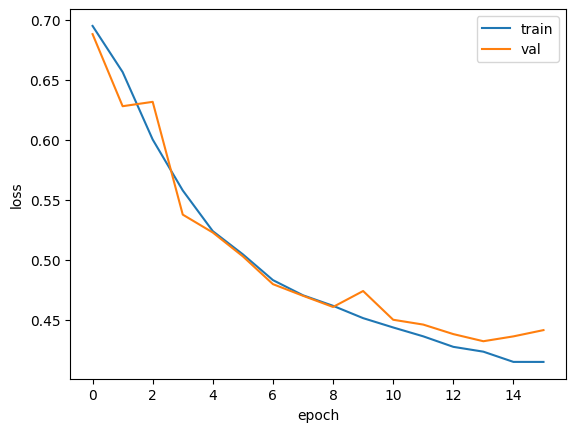

In [10]:
import matplotlib.pyplot as plt

# 훈련 손실과 검증 손실을 시각화합니다.
plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [12]:
model.load_state_dict(torch.load('besr_2lstm_model.pt', weights_only=True))

model.eval()
corrects = 0
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = outputs > 0.5
        corrects += (predicts.squeeze() == targets).sum().item()

accuracy = corrects / len(val_dataset)
print(f'검증 정확도: {accuracy:.4f}')

검증 정확도: 0.7980


In [14]:
# 테스트 세트 샘플의 길이를 100으로 맞추고 부족하면 0으로 패딩을 추가합니다.
test_seq = pad_sequences(test_input, maxlen=100)

# 텐서 데이터셋으로 변환한 후 데이터 로더에 전달해줍니다.
test_seq = torch.tensor(test_seq)
test_target = torch.tensor(test_target, dtype=torch.float32)

test_dataset = TensorDataset(test_seq, test_target)
test_loader = DataLoader(test_dataset, batch_size= 64, shuffle=False)

# 모델 평가 모드로 전환합니다.
model.eval()
corrects = 0
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = outputs > 0.5
        corrects += (predicts.squeeze() == targets).sum().item()

accuracy = corrects / len(test_dataset)
print(f'테스트 정확도: {accuracy:.4f}')

테스트 정확도: 0.7966
